<a href="https://colab.research.google.com/github/yarolava/mn/blob/labwork/lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab work #1
# Ярослава Наталіна
# КС31

# List of source datasets

[Red Wine Quality](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)


## Task 1: Data Cleaning and Preparation
**Objective:** Clean and prepare a dataset for analysis.

**Instructions:**
1. Load a dataset of your choice (from proposed Datasets).
2. Handle missing values by either removing them or imputing with appropriate values.
3. Remove any duplicate rows.
4. Convert categorical variables into numerical format using techniques like one-hot encoding (but be aware of sparse and non-sparse one-hot encoding).
5. Normalize or standardize numerical features.
6. Save the cleaned dataset to a new CSV file.

In [1]:
import pandas as pd
df = pd.read_csv("winequality-red.csv")

print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [3]:
print("Пропущені значення:\n", df.isnull().sum())

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include='number').columns.drop('quality')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.to_csv("winequality_cleaned.csv", index=False)



Пропущені значення:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## Task 2: Exploratory Data Analysis (EDA)
**Objective:** Perform exploratory data analysis to understand the dataset.

**Instructions:**
1. Use the cleaned dataset from Task 1.
2. Calculate basic statistics (mean, median, mode, standard deviation) for numerical features.
3. Visualize the distribution of numerical features using histograms and box plots.
4. Create scatter plots to visualize relationships between pairs of numerical features.
5. Use Seaborn to create a pair plot or heatmap to visualize correlations between features.
6. Summarize your findings in a short report.

Середнє:
 fixed acidity           0.000000e+00
volatile acidity       -1.045685e-17
citric acid             1.045685e-17
residual sugar          5.228423e-18
chlorides              -2.091369e-17
free sulfur dioxide     5.228423e-18
total sulfur dioxide    1.045685e-17
density                 4.182739e-17
pH                     -2.091369e-17
sulphates               0.000000e+00
alcohol                 2.091369e-17
quality                 5.623252e+00
high_quality            1.353937e-01
sulfate_alcohol         9.162093e-02
dtype: float64

Медіана:
 fixed acidity          -0.236471
volatile acidity       -0.051800
citric acid            -0.063094
residual sugar         -0.239233
chlorides              -0.184843
free sulfur dioxide    -0.181291
total sulfur dioxide   -0.264277
density                -0.004789
pH                      0.001377
sulphates              -0.226870
alcohol                -0.214775
quality                 6.000000
high_quality            0.000000
sulfate_alcohol  

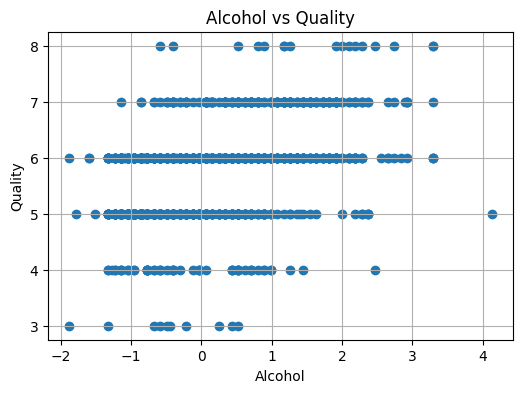

In [13]:


print("Середнє:\n", df.mean())
print("\nМедіана:\n", df.median())
print("\nМода:\n", df.mode().iloc[0])
print("\nСтандартне відхилення:\n", df.std())

# Scatter plot між двома змінними
plt.figure(figsize=(6,4))
plt.scatter(df['alcohol'], df['quality'])
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Alcohol vs Quality')
plt.grid(True)
plt.show()



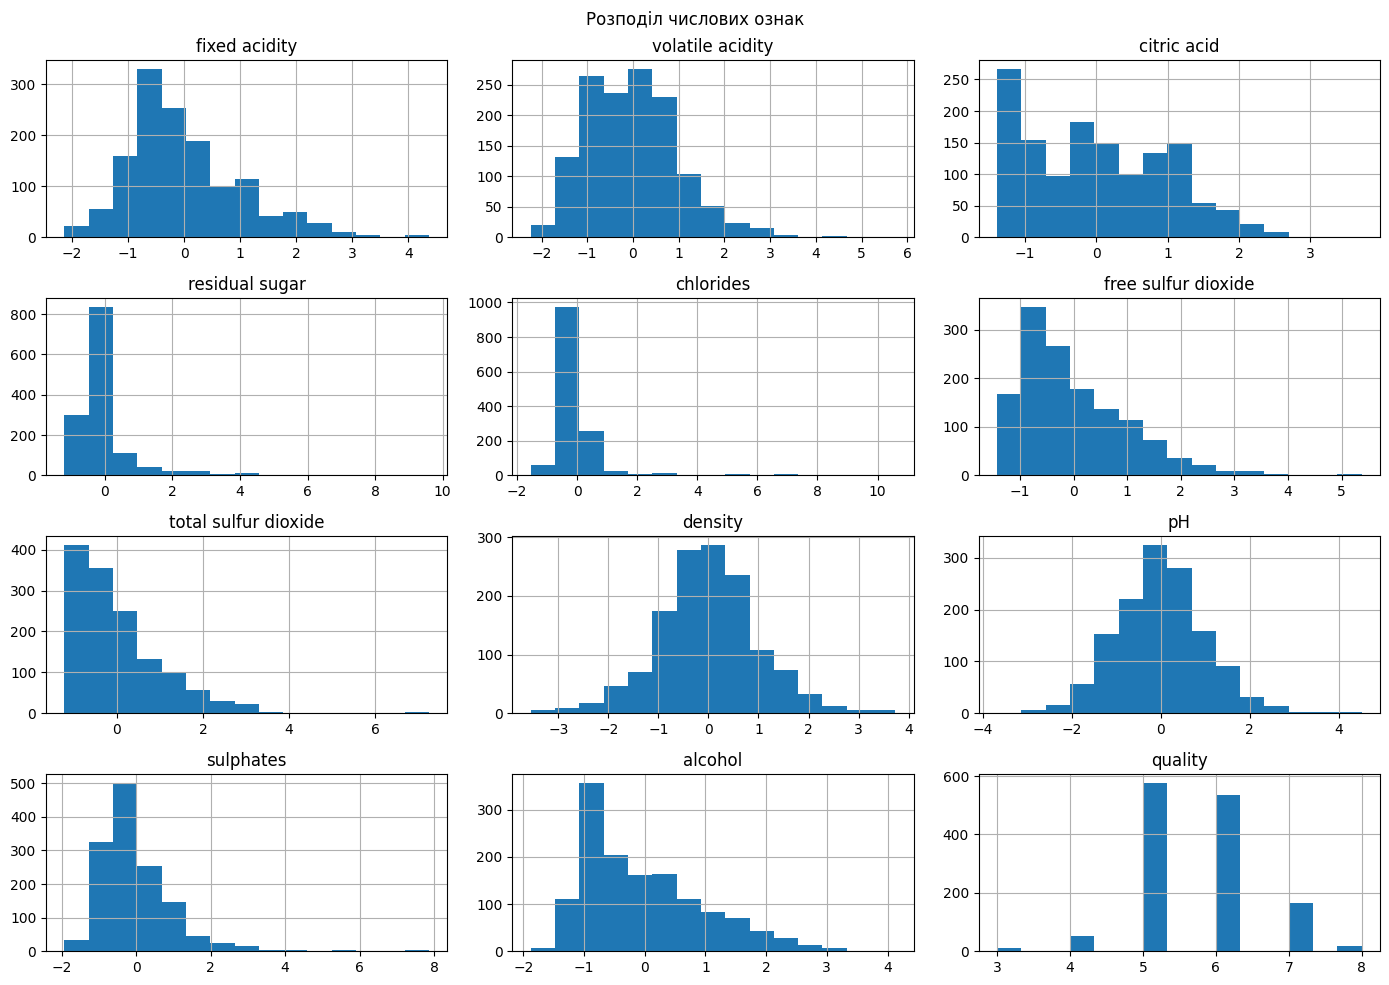

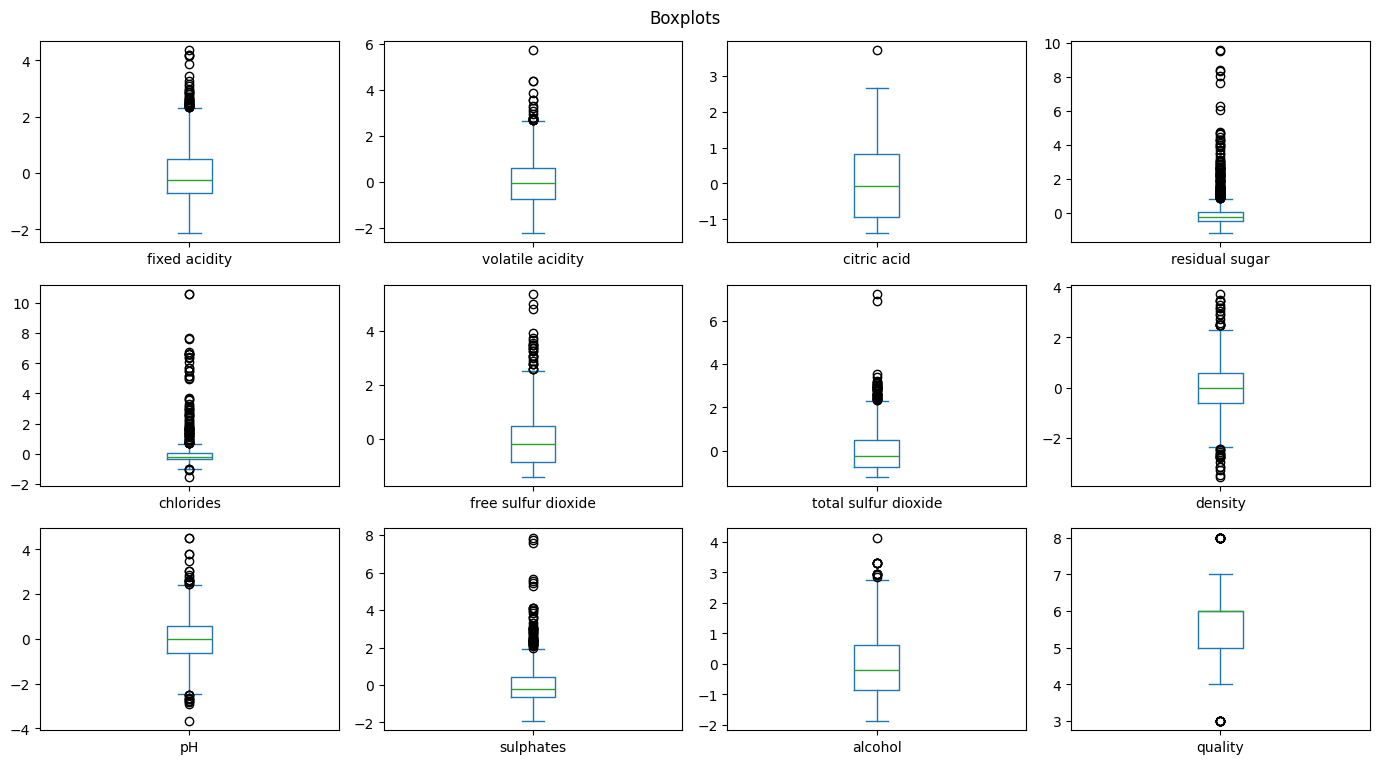

In [6]:
# Гістограми
df.hist(bins=15, figsize=(14, 10))
plt.suptitle("Розподіл числових ознак")
plt.tight_layout()
plt.show()

# Boxplots
df.plot(kind='box', subplots=True, layout=(4,4), figsize=(14,10), title="Boxplots")
plt.tight_layout()
plt.show()

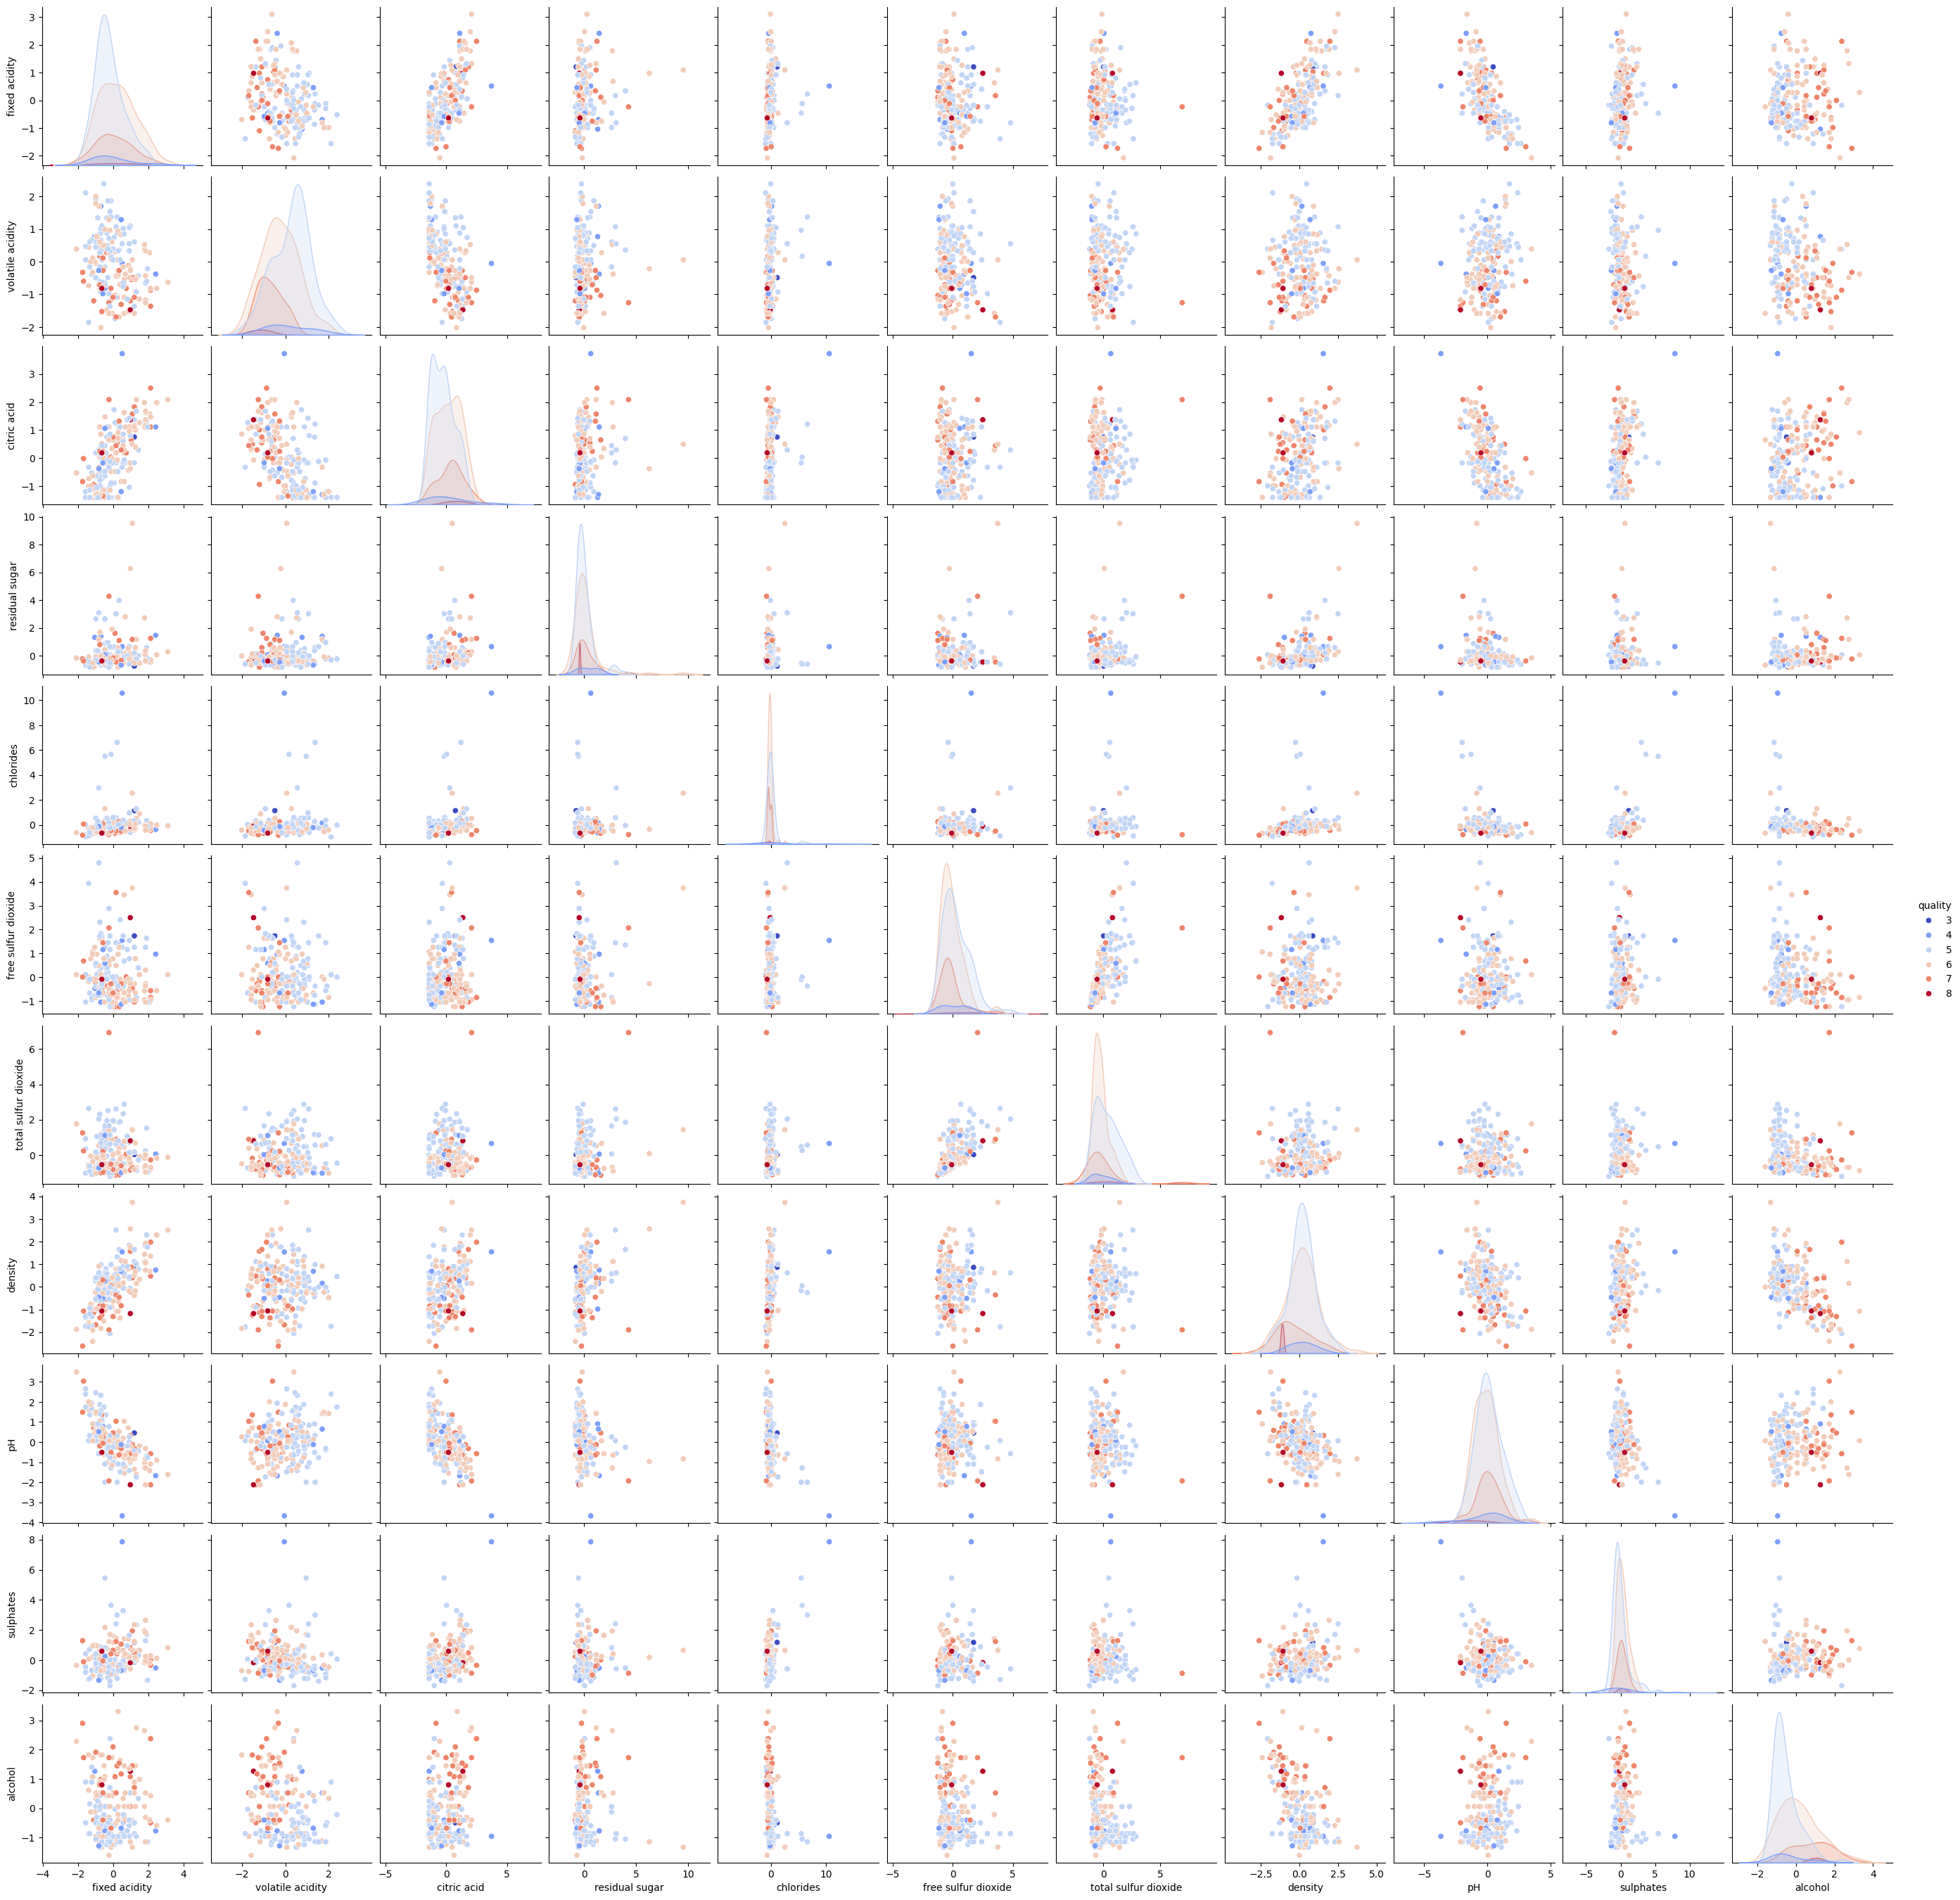

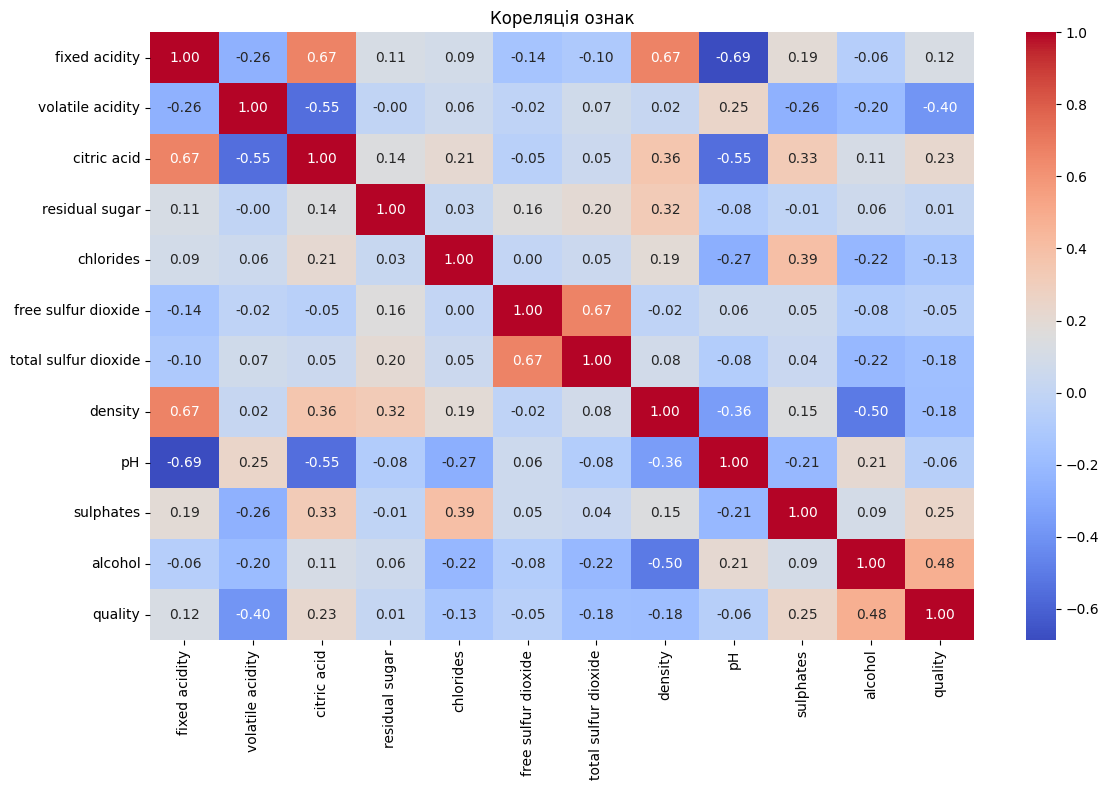

In [7]:
# Pairplot
sns.pairplot(df.sample(200), hue='quality', palette='coolwarm')  # щоб не було забагато точок
plt.show()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Кореляція ознак")
plt.tight_layout()
plt.show()

## Task 3: Feature Engineering
**Objective:** Create new features to improve the dataset's predictive power.

**Instructions:**
1. Use the cleaned dataset from Task 1.
2. Create new features based on existing ones (e.g., age groups, interaction terms).
3. Use domain knowledge to generate meaningful features.
4. Analyze the impact of the new features on the dataset's distribution and correlations.
5. Visualize the new features using appropriate plots.

Кореляція нових ознак:
 high_quality       0.706168
sulfate_alcohol    0.111351
dtype: float64


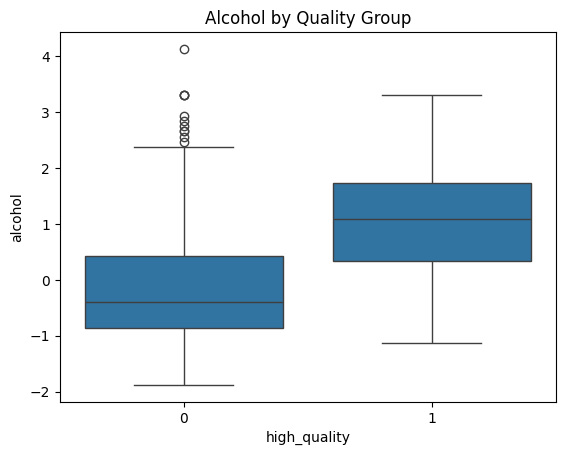

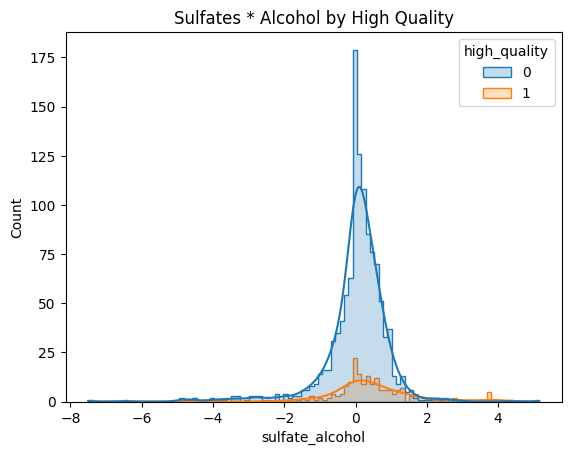

In [10]:
df['high_quality'] = (df['quality'] >= 7).astype(int)

df['sulfate_alcohol'] = df['sulphates'] * df['alcohol']

#Нові ознаки
print("Кореляція нових ознак:\n", df[['high_quality', 'sulfate_alcohol']].corrwith(df['quality']))

# Візуалізація впливу
sns.boxplot(x='high_quality', y='alcohol', data=df)
plt.title("Alcohol by Quality Group")
plt.show()

sns.histplot(data=df, x='sulfate_alcohol', hue='high_quality', kde=True, element='step')
plt.title("Sulfates * Alcohol by High Quality")
plt.show()


## Task 4: Data Visualization
**Objective:** Create insightful visualizations to communicate findings.

**Instructions:**
1. Use the dataset with new features from Task 3.
2. Create a bar chart to compare categorical features.
3. Use a line plot to show trends over time (if applicable).
4. Create a heatmap to visualize correlations between features.
5. Use Seaborn to create a violin plot or swarm plot to compare distributions across categories.
6. Combine multiple plots into a single figure using Matplotlib's subplot functionality.

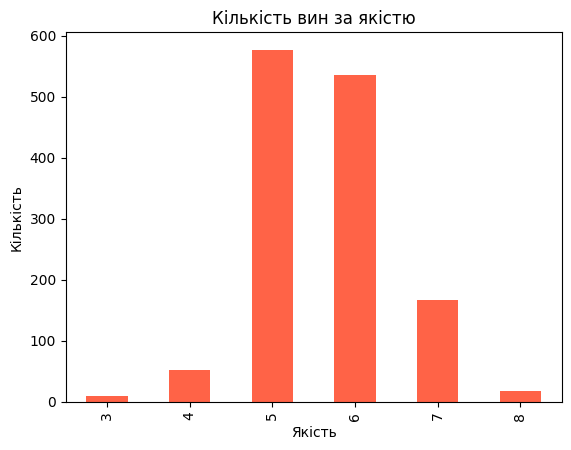

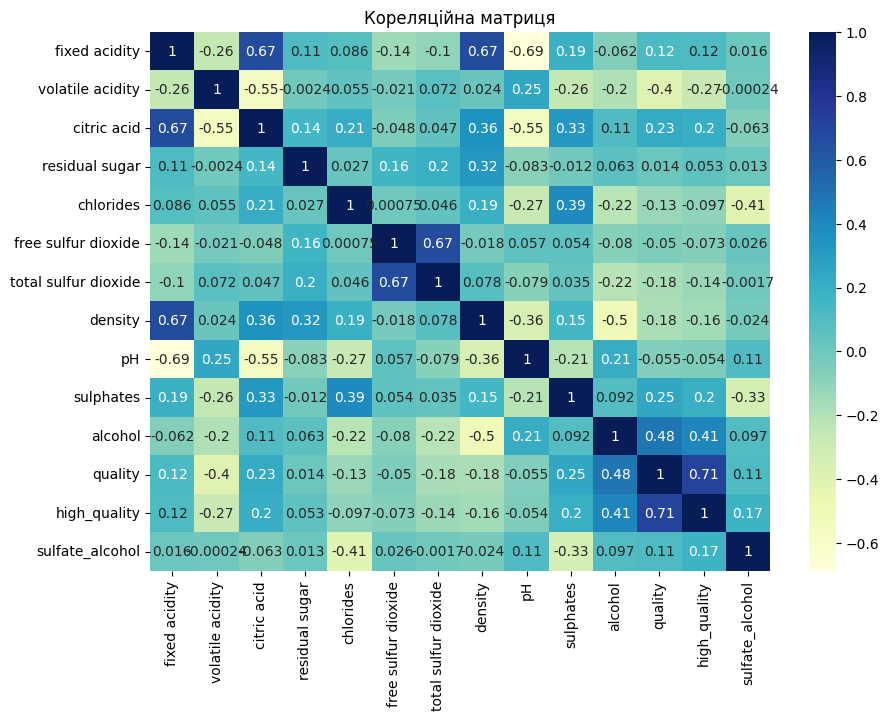

<ipython-input-9-c97a49d1a84d>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='alcohol', data=df, palette='pastel')


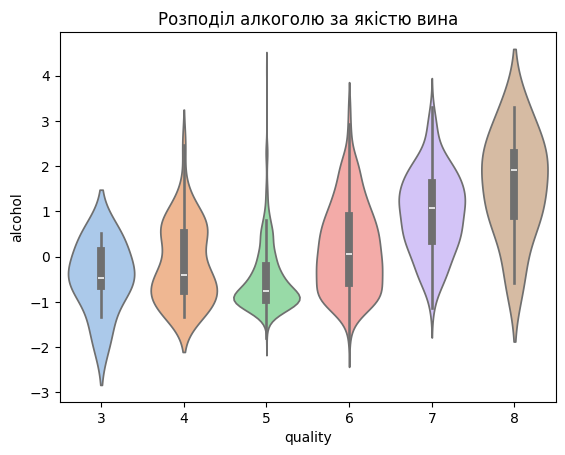

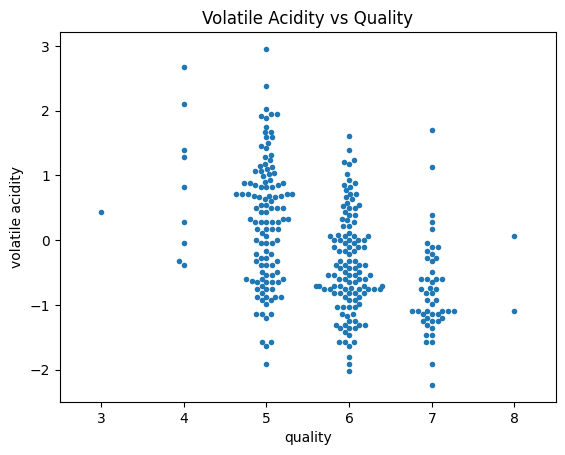

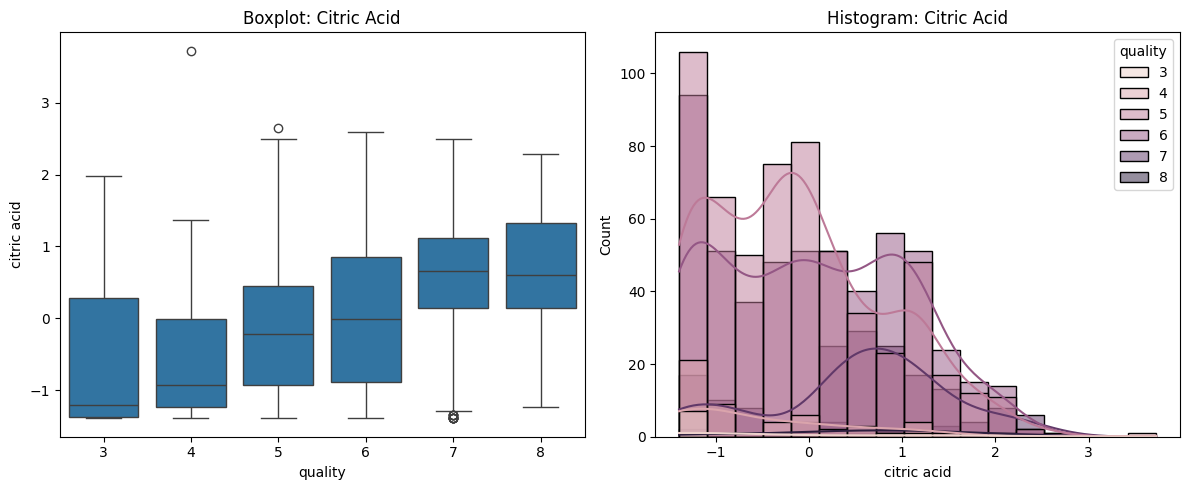

In [9]:
# Bar chart: кількість вин за рівнем якості
df['quality'].value_counts().sort_index().plot(kind='bar', color='tomato')
plt.title("Кількість вин за якістю")
plt.xlabel("Якість")
plt.ylabel("Кількість")
plt.show()

# Heatmap з кореляцією
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)
plt.title("Кореляційна матриця")
plt.show()




<ipython-input-12-5bbc80101da9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='alcohol', data=df, palette='pastel')


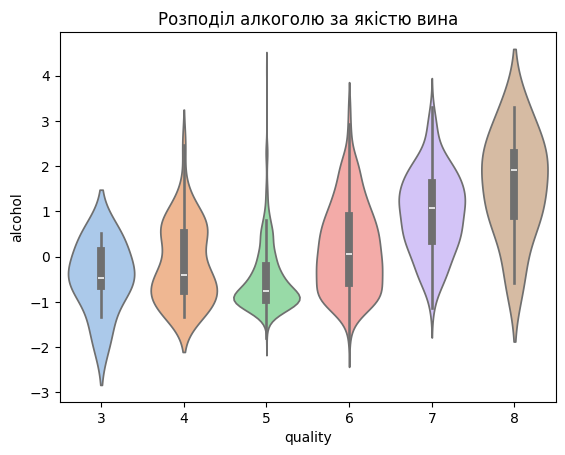

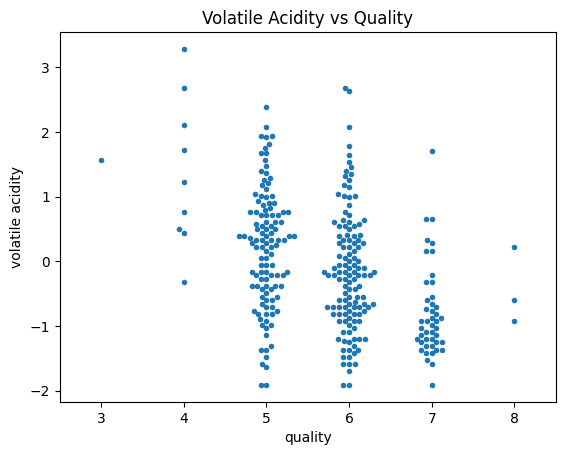

In [12]:
# Violin plot
sns.violinplot(x='quality', y='alcohol', data=df, palette='pastel')
plt.title("Розподіл алкоголю за якістю вина")
plt.show()

# Swarm plot
sns.swarmplot(x='quality', y='volatile acidity', data=df.sample(300), size=4)
plt.title("Volatile Acidity vs Quality")
plt.show()

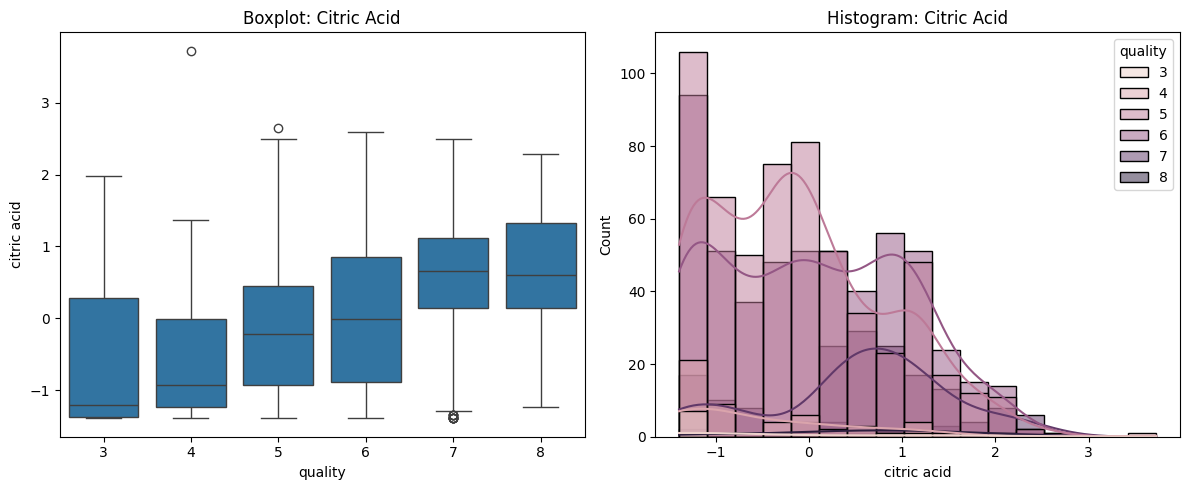

In [11]:
# Subplots: Boxplot + Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='quality', y='citric acid', ax=axes[0])
axes[0].set_title("Boxplot: Citric Acid")
sns.histplot(data=df, x='citric acid', hue='quality', kde=True, ax=axes[1])
axes[1].set_title("Histogram: Citric Acid")
plt.tight_layout()
plt.show()